In [1]:
# === ノートブック共通の前処理 (llm_math パッケージの読み込み) ===
import sys
from pathlib import Path

# llm_math パッケージの候補パス
_candidates = [
    '.', 'src', '..', '../src',
    '/content/llm-math-book/src',
    '/content/llm-math-book',
    '/workspace/src',
    '/workspace',
]
# 親ディレクトリも候補に追加 (notebooks/ フォルダで実行する場合)
for p in Path.cwd().parents:
    _candidates.append(str(p / 'src'))
    _candidates.append(str(p))

for p in _candidates:
    if p and p not in sys.path and Path(p).exists():
        sys.path.insert(0, p)

# llm_math の import を試行
try:
    from llm_math import viz, bench, data
    _LLM_MATH_OK = True
except ImportError as e:
    _LLM_MATH_OK = False
    print(f"[注意] llm_math パッケージの読み込み テキスト: {e}")
    print("  GitHub リポジトリを clone して colab_setup.sh を実行してください。")
# === 前処理ここまで ===


# Ch 09. テキスト テキスト — SGDテキスト Lionテキスト ⭐

> **学習目標**
> - SGD, Momentum, RMSProp, Adam, AdamW, Lionテキスト テキスト テキスト度テキスト
> - 1テキスト テキスト $\mathbf{m}$, 2テキスト テキスト $\mathbf{v}$テキスト テキスト テキスト
> - 学習テキスト テキスト(Warmup, Cosine, WSD)テキスト テキスト
> - テキスト テキスト 速度テキスト テキスト テキスト 比較テキスト

## 9.1 SGDテキスト テキスト

**Stochastic Gradient Descent**:
$$\theta_{t+1} = \theta_t - \eta \, \mathbf{g}_t, \quad \mathbf{g}_t = \nabla_\theta \mathcal{L}(\theta_t; \mathcal{B}_t)$$

- $\mathcal{B}_t$: $t$テキスト テキスト
- $\eta$: 学習テキスト

テキスト データ テキスト テキスト テキスト テキスト → テキスト テキスト テキスト.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# テキスト 関数テキスト
def bowl(x, y):
    return x**2 + 5 * y**2  # テキスト, yテキスト テキスト

def bowl_grad(x, y):
    return np.array([2*x, 10*y])

# SGD
def sgd(grad_fn, x0, lr=0.1, n_steps=100):
    path = [np.array(x0, dtype=float)]
    x = np.array(x0, dtype=float)
    for _ in range(n_steps):
        g = grad_fn(*x)
        x = x - lr * g
        path.append(x.copy())
    return np.array(path)

path_sgd = sgd(bowl_grad, [2.0, 2.0], lr=0.1, n_steps=50)
print(f"SGD 50Step テキスト: {path_sgd[-1]} (MinimumPoint (0, 0))")
print(f"テキスト Loss: {bowl(*path_sgd[-1]):.2e}")


SGD 50Step テキスト: [2.85449539e-05 0.00000000e+00] (MinimumPoint (0, 0))
テキスト Loss: 8.15e-10


## 9.2 Momentum — テキスト テキスト テキスト

$$\mathbf{v}_t = \beta \mathbf{v}_{t-1} + \mathbf{g}_t$$
$$\theta_{t+1} = \theta_t - \eta \, \mathbf{v}_t$$

- $\beta \approx 0.9$: テキスト テキスト テキスト テキスト テキスト
- テキスト 方向テキスト テキスト テキスト, テキスト 方向テキスト テキスト
- テキスト テキスト: テキスト テキスト テキスト テキスト


Momentum 50Step テキスト: [-0.06099686 -0.0993047 ]
テキスト Loss: 5.30e-02


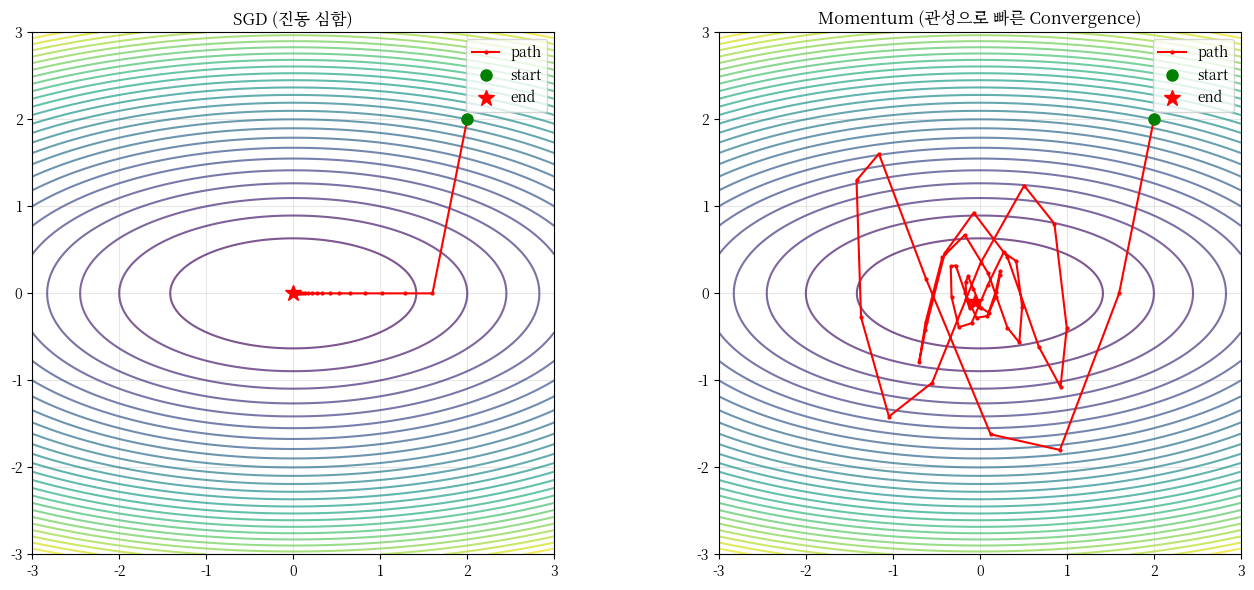

In [3]:
# Momentum
def momentum(grad_fn, x0, lr=0.1, beta=0.9, n_steps=100):
    path = [np.array(x0, dtype=float)]
    x = np.array(x0, dtype=float)
    v = np.zeros_like(x)
    for _ in range(n_steps):
        g = grad_fn(*x)
        v = beta * v + g
        x = x - lr * v
        path.append(x.copy())
    return np.array(path)

path_momentum = momentum(bowl_grad, [2.0, 2.0], lr=0.1, beta=0.9, n_steps=50)
print(f"Momentum 50Step テキスト: {path_momentum[-1]}")
print(f"テキスト Loss: {bowl(*path_momentum[-1]):.2e}")

# 可視化
from llm_math.viz import plot_contour_and_path
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_contour_and_path(axes[0], lambda v: bowl(*v), path_sgd, xlim=(-3, 3), ylim=(-3, 3),
                      title='SGD (テキスト テキスト)')
plot_contour_and_path(axes[1], lambda v: bowl(*v), path_momentum, xlim=(-3, 3), ylim=(-3, 3),
                      title='Momentum (テキスト テキスト Convergence)')
plt.tight_layout()
plt.savefig('../figures/ch09_sgd_vs_momentum.png', dpi=100, bbox_inches='tight')
plt.show()


## 9.3 テキスト 学習テキスト — AdaGrad, RMSProp

**AdaGrad**: テキスト テキスト 学習テキスト. テキスト テキスト テキスト テキスト.
$$\mathbf{r}_t = \mathbf{r}_{t-1} + \mathbf{g}_t^2$$
$$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\mathbf{r}_t + \epsilon}} \mathbf{g}_t$$

問題: $\mathbf{r}$テキスト テキスト テキスト 学習テキスト テキスト.

**RMSProp**: テキスト テキスト テキスト
$$\mathbf{v}_t = \beta \mathbf{v}_{t-1} + (1-\beta) \mathbf{g}_t^2$$
$$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\mathbf{v}_t + \epsilon}} \mathbf{g}_t$$

## 9.4 Adam — 1テキスト + 2テキスト テキスト

**Adam** = Momentum + RMSProp
$$\mathbf{m}_t = \beta_1 \mathbf{m}_{t-1} + (1-\beta_1) \mathbf{g}_t$$  (1テキスト テキスト)
$$\mathbf{v}_t = \beta_2 \mathbf{v}_{t-1} + (1-\beta_2) \mathbf{g}_t^2$$  (2テキスト テキスト)

テキスト テキスト (テキスト値テキスト 0テキスト early stepテキスト テキスト テキスト 問題):
$$\hat{\mathbf{m}}_t = \frac{\mathbf{m}_t}{1 - \beta_1^t}, \quad \hat{\mathbf{v}}_t = \frac{\mathbf{v}_t}{1 - \beta_2^t}$$

テキスト:
$$\theta_{t+1} = \theta_t - \eta \frac{\hat{\mathbf{m}}_t}{\sqrt{\hat{\mathbf{v}}_t} + \epsilon}$$

- $\beta_1 = 0.9, \beta_2 = 0.999, \epsilon = 10^{-8}$ (テキスト値)
- LLM 学習テキスト テキスト テキスト


Adam 50Step テキスト: [-0.075764 -0.075764]
テキスト Loss: 3.44e-02


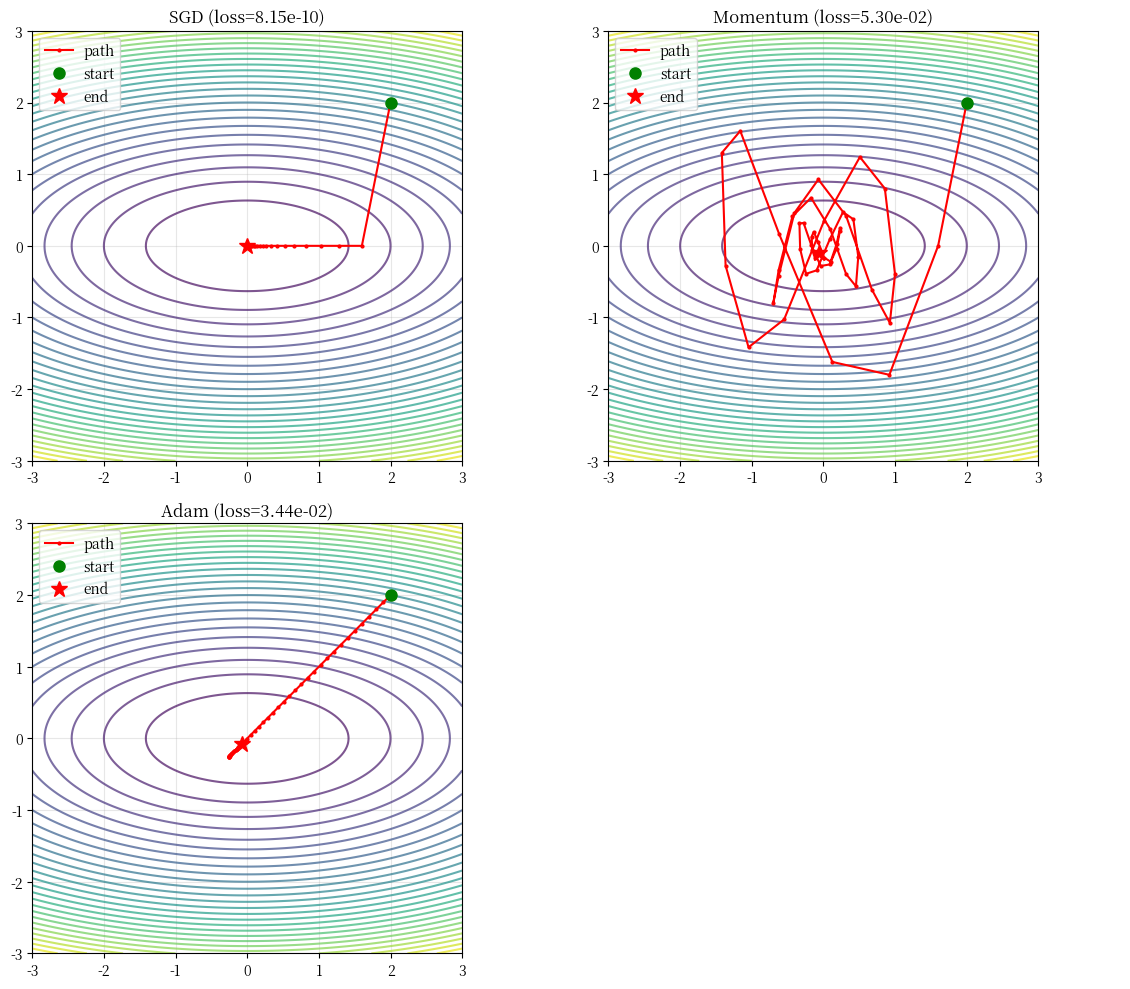

In [4]:
# Adam テキスト テキスト
class Adam:
    def __init__(self, params, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.params = params  # dict of arrays
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.m = {k: np.zeros_like(v) for k, v in params.items()}
        self.v = {k: np.zeros_like(v) for k, v in params.items()}
        self.t = 0

    def step(self, grads):
        self.t += 1
        for k in self.params:
            self.m[k] = self.beta1 * self.m[k] + (1 - self.beta1) * grads[k]
            self.v[k] = self.beta2 * self.v[k] + (1 - self.beta2) * grads[k]**2
            m_hat = self.m[k] / (1 - self.beta1**self.t)
            v_hat = self.v[k] / (1 - self.beta2**self.t)
            self.params[k] -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

# テキスト 2D 関数テキスト テキスト
def adam_optimize(grad_fn, x0, lr=0.1, n_steps=100):
    x = np.array(x0, dtype=float)
    params = {'x': x}
    opt = Adam(params, lr=lr)
    path = [x.copy()]
    for _ in range(n_steps):
        g = grad_fn(*x)
        opt.step({'x': g})
        x = params['x']
        path.append(x.copy())
    return np.array(path)

path_adam = adam_optimize(bowl_grad, [2.0, 2.0], lr=0.1, n_steps=50)
print(f"Adam 50Step テキスト: {path_adam[-1]}")
print(f"テキスト Loss: {bowl(*path_adam[-1]):.2e}")

# 4テキスト Optimizer Comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (path, name) in zip(axes.flat, [
    (path_sgd, 'SGD'),
    (path_momentum, 'Momentum'),
    (path_adam, 'Adam'),
]):
    plot_contour_and_path(ax, lambda v: bowl(*v), path, xlim=(-3, 3), ylim=(-3, 3),
                          title=f'{name} (loss={bowl(*path[-1]):.2e})')
# テキスト テキスト テキスト
axes[1, 1].axis('off')
plt.tight_layout()
plt.savefig('../figures/ch09_optimizers_comparison.png', dpi=100, bbox_inches='tight')
plt.show()


## 9.5 AdamW — テキスト テキスト テキスト テキスト

Adamテキスト テキスト テキスト(weight decay)テキスト テキスト テキスト, テキスト テキスト テキスト度テキスト テキスト テキスト テキスト.

**AdamW** (Decoupled Weight Decay):
$$\theta_{t+1} = \theta_t - \eta \left( \frac{\hat{\mathbf{m}}_t}{\sqrt{\hat{\mathbf{v}}_t} + \epsilon} + \lambda \theta_t \right)$$

- テキスト テキスト $\lambda \theta_t$テキスト テキスト テキスト テキスト テキスト テキスト
- LLM 学習テキスト テキスト テキスト (GPT, LLaMA テキスト AdamW テキスト)


In [5]:
# AdamW vs Adam (L2 テキスト)
class AdamW:
    def __init__(self, params, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8, weight_decay=0.01):
        self.params = params
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.wd = weight_decay
        self.m = {k: np.zeros_like(v) for k, v in params.items()}
        self.v = {k: np.zeros_like(v) for k, v in params.items()}
        self.t = 0

    def step(self, grads):
        self.t += 1
        for k in self.params:
            self.m[k] = self.beta1 * self.m[k] + (1 - self.beta1) * grads[k]
            self.v[k] = self.beta2 * self.v[k] + (1 - self.beta2) * grads[k]**2
            m_hat = self.m[k] / (1 - self.beta1**self.t)
            v_hat = self.v[k] / (1 - self.beta2**self.t)
            # テキスト テキスト テキスト テキスト テキスト テキスト テキスト
            self.params[k] -= self.lr * (m_hat / (np.sqrt(v_hat) + self.eps) + self.wd * self.params[k])

# AdamW テキスト: テキスト テキスト テキスト
print("AdamW Weight テキスト Effect:")
params = {'w': np.array([10.0, 10.0, 10.0])}
opt = AdamW(params, lr=0.1, weight_decay=0.1)
for i in range(10):
    grad = {'w': np.array([0.01, 0.01, 0.01])}  # テキスト Gradient
    opt.step(grad)
    print(f"  step {i+1}: w = {params['w'].round(4)}")
print("\n=> Weightテキスト 0テキスト テキスト Decreaseテキスト (Weight テキスト).")


AdamW Weight テキスト Effect:
  step 1: w = [9.8 9.8 9.8]
  step 2: w = [9.602 9.602 9.602]
  step 3: w = [9.406 9.406 9.406]
  step 4: w = [9.2119 9.2119 9.2119]
  step 5: w = [9.0198 9.0198 9.0198]
  step 6: w = [8.8296 8.8296 8.8296]
  step 7: w = [8.6413 8.6413 8.6413]
  step 8: w = [8.4549 8.4549 8.4549]
  step 9: w = [8.2703 8.2703 8.2703]
  step 10: w = [8.0876 8.0876 8.0876]

=> Weightテキスト 0テキスト テキスト Decreaseテキスト (Weight テキスト).


## 9.6 学習テキスト テキスト

テキスト 学習テキスト テキスト テキスト テキスト テキスト テキスト.

- **Warmup**: テキスト $N$テキスト テキスト テキスト. テキスト テキスト.
- **Cosine**: $\eta_t = \eta_{\min} + \frac{1}{2}(\eta_{\max} - \eta_{\min})(1 + \cos(\pi t / T))$
- **WSD (Warmup-Stable-Decay)**: テキスト LLM テキスト. テキスト テキスト テキスト テキスト.


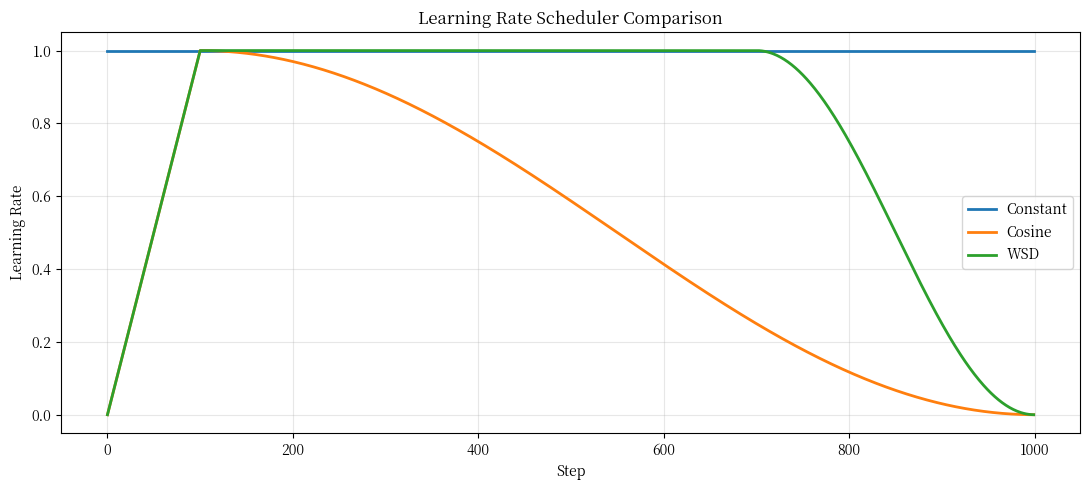

In [6]:
# テキスト テキスト テキスト 可視化
def constant_lr(t, max_t, lr_max=1.0, warmup=0):
    return lr_max

def cosine_lr(t, max_t, lr_max=1.0, lr_min=0.0, warmup=0):
    if t < warmup:
        return lr_max * t / warmup
    progress = (t - warmup) / (max_t - warmup)
    return lr_min + 0.5 * (lr_max - lr_min) * (1 + np.cos(np.pi * progress))

def wsd_lr(t, max_t, lr_max=1.0, lr_min=0.0, warmup=100, stable_end=0.8):
    """Warmup-Stable-Decay."""
    if t < warmup:
        return lr_max * t / warmup
    elif t < stable_end * max_t:
        return lr_max
    else:
        progress = (t - stable_end * max_t) / (max_t - stable_end * max_t)
        return lr_min + 0.5 * (lr_max - lr_min) * (1 + np.cos(np.pi * progress))

t = np.arange(1000)
fig, ax = plt.subplots(figsize=(11, 5))
for name, fn in [
    ('Constant', lambda t: constant_lr(t, 1000, 1.0, 100)),
    ('Cosine', lambda t: cosine_lr(t, 1000, 1.0, 0.0, 100)),
    ('WSD', lambda t: wsd_lr(t, 1000, 1.0, 0.0, 100, 0.7)),
]:
    ax.plot(t, [fn(ti) for ti in t], label=name, linewidth=2)
ax.set_xlabel('Step'); ax.set_ylabel('Learning Rate')
ax.set_title('Learning Rate Scheduler Comparison')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/ch09_lr_schedules.png', dpi=100, bbox_inches='tight')
plt.show()


## 9.7 テキスト テキスト

$$\mathbf{g} \leftarrow \frac{\mathbf{g}}{\max(1, \|\mathbf{g}\| / c)}$$

テキスト テキスト テキスト. $c$テキスト テキスト 1.0. LLM 学習テキスト テキスト.


In [7]:
# テキスト テキスト
def clip_grad_norm(grad, max_norm=1.0):
    norm = np.linalg.norm(grad)
    if norm > max_norm:
        grad = grad * (max_norm / norm)
    return grad, norm

# テキスト
np.random.seed(0)
small_grad = np.random.randn(3) * 0.1
big_grad = np.random.randn(3) * 100

clipped_small, norm_small = clip_grad_norm(small_grad, 1.0)
clipped_big, norm_big = clip_grad_norm(big_grad, 1.0)

print(f"テキスト Gradient: norm={norm_small:.4f} -> テキスト テキスト norm={np.linalg.norm(clipped_small):.4f} (Change テキスト)")
print(f"テキスト Gradient:   norm={norm_big:.4f} -> テキスト テキスト norm={np.linalg.norm(clipped_big):.4f} (1.0テキスト テキスト)")


テキスト Gradient: norm=0.2057 -> テキスト テキスト norm=0.2057 (Change テキスト)
テキスト Gradient:   norm=307.6434 -> テキスト テキスト norm=1.0000 (1.0テキスト テキスト)


## 9.8 [CPU/GPU ベンチマーク ③] テキスト テキスト·時間 比較

PyTorchテキスト テキスト 比較テキスト テキスト.


Training with SGD...


  テキスト loss: 0.8102
Training with Momentum...


  テキスト loss: 0.5276
Training with Adam...


  テキスト loss: 0.5370
Training with AdamW...


  テキスト loss: 0.5376


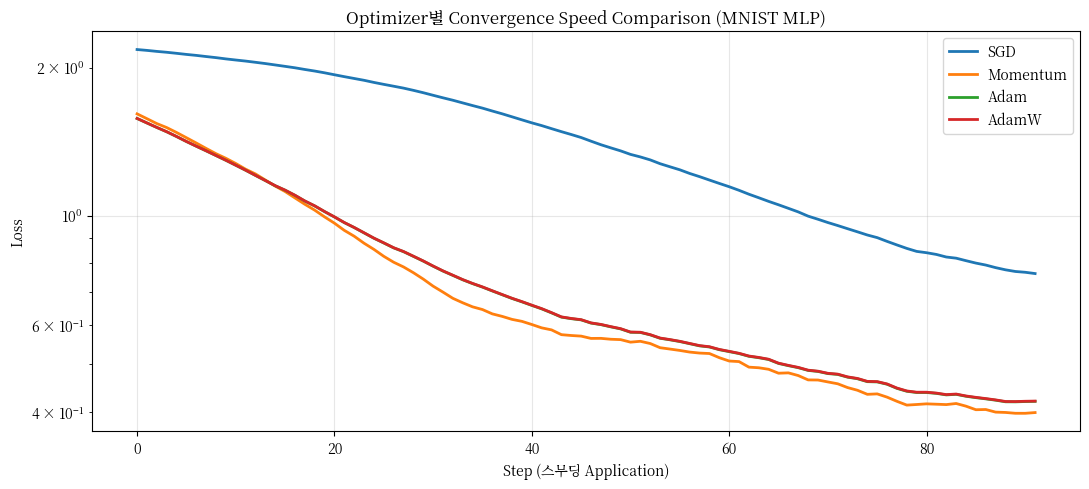


=> Adam/AdamWテキスト SGDテキスト テキスト テキスト Convergenceテキスト. LLM Trainingテキスト AdamWテキスト Standard.


In [8]:
# テキスト 比較 (PyTorch)
import torch
import torch.nn as nn
from llm_math.data import load_mnist_small

X_train, y_train, X_test, y_test = load_mnist_small(n_train=3000, n_test=1000)
X_t = torch.tensor(X_train, dtype=torch.float32)
y_t = torch.tensor(y_train, dtype=torch.long)

def train_with_optim(opt_name, n_epochs=5, batch_size=64):
    torch.manual_seed(0)
    model = nn.Sequential(
        nn.Linear(784, 128), nn.ReLU(),
        nn.Linear(128, 64), nn.ReLU(),
        nn.Linear(64, 10)
    )
    if opt_name == 'SGD':
        opt = torch.optim.SGD(model.parameters(), lr=0.1)
    elif opt_name == 'Momentum':
        opt = torch.optim.SGD(model.parameters(), lr=0.05, momentum=0.9)
    elif opt_name == 'Adam':
        opt = torch.optim.Adam(model.parameters(), lr=0.001)
    elif opt_name == 'AdamW':
        opt = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

    loss_fn = nn.CrossEntropyLoss()
    losses = []
    for epoch in range(n_epochs):
        idx = torch.randperm(len(X_t))
        for i in range(0, len(X_t), batch_size):
            bi = idx[i:i+batch_size]
            xb, yb = X_t[bi], y_t[bi]
            opt.zero_grad()
            out = model(xb)
            loss = loss_fn(out, yb)
            loss.backward()
            opt.step()
            losses.append(loss.item())
    return losses

# テキスト Optimizer テキスト
results = {}
for name in ['SGD', 'Momentum', 'Adam', 'AdamW']:
    print(f"Training with {name}...")
    losses = train_with_optim(name, n_epochs=3)
    results[name] = losses
    print(f"  テキスト loss: {losses[-1]:.4f}")

# Visualization
fig, ax = plt.subplots(figsize=(11, 5))
for name, losses in results.items():
    # テキスト Meanテキスト テキスト
    window = 50
    smoothed = np.convolve(losses, np.ones(window)/window, mode='valid')
    ax.plot(smoothed, label=name, linewidth=2)
ax.set_xlabel('Step (テキスト Application)')
ax.set_ylabel('Loss')
ax.set_title('Optimizerテキスト Convergence Speed Comparison (MNIST MLP)')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_yscale('log')
plt.tight_layout()
plt.savefig('../figures/ch09_optimizers_mnist.png', dpi=100, bbox_inches='tight')
plt.show()
print("\n=> Adam/AdamWテキスト SGDテキスト テキスト テキスト Convergenceテキスト. LLM Trainingテキスト AdamWテキスト Standard.")


## 9.9 要点

| テキスト | テキスト テキスト | テキスト テキスト テキスト |
|---|---|---|
| SGD | テキスト テキスト | 0 |
| Momentum | 1テキスト テキスト (テキスト) | 1テキスト |
| RMSProp | 2テキスト テキスト (テキスト lr) | 1テキスト |
| Adam | 1テキスト + 2テキスト テキスト | 2テキスト |
| AdamW | Adam + テキスト テキスト テキスト | 2テキスト |

## 演習問題

1. SGD, Momentum, Adamテキスト Rosenbrock 関数テキスト テキスト テキスト テキスト 比較テキスト.
2. Adamテキスト テキスト テキスト テキスト テキスト early stepテキスト $\mathbf{m}_t$テキスト テキスト 比較テキスト テキスト.
3. Adam vs AdamWテキスト テキスト テキスト 0.01テキスト テキスト MNISTテキスト 比較テキスト.
4. 学習テキスト $10^{-2}, 10^{-3}, 10^{-4}$テキスト Adamテキスト テキスト テキスト 速度テキスト 比較テキスト.
5. Warmup テキスト テキスト テキスト LLM 学習テキスト テキスト テキスト テキスト.

> 解答: `solutions/ch09_solutions.ipynb`
